# Test Cloud Type Classification Accuracy

This notebook tests the MCS swath creation and cloud type classification functions.

**Key Functions:**
1. `create_track_swaths_and_coverage()` - Create MCS track swaths and coverage from 3D track number array
2. `combine_swaths_with_priority()` - Combine multiple track swaths, resolving overlaps by coverage count
3. `classify_cloud_types()` - Classify cloud types based on brightness temperature and precipitation
4. `find_most_frequent_cloud_type()` - Find most frequent cloud type over time for each cell

In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import yaml
import calendar
import os
import sys
import intake
import easygems.healpix as egh
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path
import colormaps as cmaps
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import cartopy.crs as ccrs
import warnings

# Add parent directory to path for imports
sys.path.append('/global/homes/f/feng045/program/waccem/gsrm_cooccurrencefeature')
from pyflextrkr.ft_utilities import load_config
from pyflextrkr.ftfunctions import olr_to_tb

mpl.rcParams['figure.dpi'] = 150

## 1. Define Helper Functions

Extract key functions from the main script for testing.

In [3]:
def convert_cftime_to_standard_calendar(cftime_times):
    """
    Convert cftime datetime objects (non-standard calendars) to numpy datetime64 (standard calendar).
    """
    is_single_object = not hasattr(cftime_times, '__iter__')
    times_list = [cftime_times] if is_single_object else cftime_times
    
    converted_times = []
    for t in times_list:
        if isinstance(t, (np.datetime64, pd.Timestamp)):
            converted_times.append(np.datetime64(t, 'ns'))
        elif hasattr(t, 'year'):
            try:
                pd_time = pd.Timestamp(
                    year=t.year, month=t.month, day=t.day,
                    hour=t.hour, minute=t.minute, second=t.second
                )
                converted_times.append(pd_time.to_datetime64())
            except ValueError as e:
                print(f"Warning: Could not convert {t} to standard calendar: {e}")
                last_day = calendar.monthrange(t.year, t.month)[1]
                adjusted_day = min(t.day, last_day)
                pd_time = pd.Timestamp(
                    year=t.year, month=t.month, day=adjusted_day,
                    hour=t.hour, minute=t.minute, second=t.second
                )
                converted_times.append(pd_time.to_datetime64())
        else:
            raise TypeError(f"Unsupported time type: {type(t)}")
    
    if is_single_object:
        return converted_times[0]
    else:
        return np.array(converted_times, dtype='datetime64[ns]')

In [4]:
def create_track_swaths_and_coverage(tracknumber):
    """
    Create track swaths and coverage count arrays from a 3D track number array.
    
    Parameters:
    -----------
    tracknumber : numpy.ndarray
        3D array with dimensions (time, y, x) containing track numbers at each timestep.
        Background/no-track pixels should be 0.
    
    Returns:
    --------
    track_swaths_dict : dict
        Dictionary with track_id as keys and 2D swath arrays as values.
    track_coverage_dict : dict
        Dictionary with track_id as keys and 2D coverage count arrays as values.
    """
    # Get unique track numbers (excluding 0 which is background)
    unique_tracks = np.unique(tracknumber)
    unique_tracks = unique_tracks[unique_tracks > 0]
    
    # Initialize dictionaries
    track_swaths_dict = {}
    track_coverage_dict = {}
    
    # Process each unique track using vectorized operations
    for track_id in unique_tracks:
        # Create binary mask for this track across all timesteps
        track_mask = (tracknumber == track_id).astype(int)
        
        # Track swath: all pixels covered by this track labeled with track number
        swath = np.any(track_mask, axis=0).astype(int) * track_id
        track_swaths_dict[track_id] = swath
        
        # Coverage count: number of times each pixel is covered
        coverage = np.sum(track_mask, axis=0)
        track_coverage_dict[track_id] = coverage
    
    return track_swaths_dict, track_coverage_dict

In [5]:
def combine_swaths_with_priority(track_swaths_dict, track_coverage_dict):
    """
    Combine multiple track swaths into a single 2D array, resolving overlaps
    by assigning the track number with the largest coverage count.
    
    Parameters:
    -----------
    track_swaths_dict : dict
        Dictionary with track_id as keys and 2D swath arrays as values
    track_coverage_dict : dict
        Dictionary with track_id as keys and 2D coverage count arrays as values
    
    Returns:
    --------
    combined_swath : numpy.ndarray
        2D array with combined swaths
    """
    # Get the shape from the first swath
    first_key = list(track_swaths_dict.keys())[0]
    shape = track_swaths_dict[first_key].shape
    
    # Initialize output array
    combined_swath = np.zeros(shape, dtype=int)
    max_coverage = np.zeros(shape, dtype=int)
    
    # Process each track using vectorized operations
    for track_id in track_swaths_dict.keys():
        swath = track_swaths_dict[track_id]
        coverage = track_coverage_dict[track_id]
        
        track_mask = swath > 0
        update_mask = track_mask & ((combined_swath == 0) | (coverage > max_coverage))
        
        combined_swath = np.where(update_mask, track_id, combined_swath)
        max_coverage = np.where(update_mask, coverage, max_coverage)
    
    return combined_swath

In [6]:
def create_latitude_dependent_tb_threshold(lat_values):
    """
    Create latitude-dependent brightness temperature thresholds.
    
    Parameters:
    -----------
    lat_values : numpy.ndarray
        Array of latitude values
        
    Returns:
    --------
    tb_thresh : numpy.ndarray
        Array of temperature thresholds (K)
    """
    abs_lat = np.abs(lat_values)
    tb_thresh = np.zeros_like(lat_values, dtype=np.float32)
    
    # Tropics: |lat| <= 30, tb_thresh = 250 K
    tropical_mask = abs_lat <= 30
    tb_thresh[tropical_mask] = 250.0
    
    # Mid-latitudes: 30 < |lat| <= 60, linearly decrease from 250 to 230 K
    midlat_mask = (abs_lat > 30) & (abs_lat <= 60)
    tb_thresh[midlat_mask] = 250.0 - 20.0 * ((abs_lat[midlat_mask] - 30.0) / 30.0)
    
    # High latitudes: |lat| > 60, tb_thresh = 230 K
    highlat_mask = abs_lat > 60
    tb_thresh[highlat_mask] = 230.0
    
    return tb_thresh

In [7]:
def classify_cloud_types(tb, pr, tb_thresh, mcs_mask, pr_threshold=0.5):
    """
    Classify cloud types based on brightness temperature and precipitation.
    
    Parameters:
    -----------
    tb : numpy.ndarray
        Brightness temperature (K)
    pr : numpy.ndarray
        Precipitation rate (mm/h)
    tb_thresh : numpy.ndarray
        Latitude-dependent brightness temperature threshold (K)
    mcs_mask : numpy.ndarray
        MCS mask array (values > 0 indicate MCS pixels)
        Classification only occurs where mcs_mask == 0 (non-MCS areas)
    pr_threshold : float, optional
        Precipitation threshold for classification (default: 0.5 mm/h)
    
    Returns:
    --------
    cloud_type : numpy.ndarray
        Cloud type classification:
        0 = Unclassified (inside MCS regions)
        1 = Deep convective (tb < tb_thresh & pr >= pr_threshold)
        2 = Stratiform (tb < tb_thresh & pr < pr_threshold)
        3 = Non-deep convective (tb >= tb_thresh & pr >= pr_threshold)
        4 = Drizzle (tb >= tb_thresh & pr < pr_threshold)
    """
    # Initialize cloud type array with zeros
    cloud_type = np.zeros_like(tb, dtype=np.int8)
    
    # Only classify where mcs_mask == 0 (non-MCS areas)
    valid_mask = mcs_mask == 0
    
    # Classification conditions
    deep_conv = (tb < tb_thresh) & (pr >= pr_threshold) & valid_mask
    cloud_type[deep_conv] = 1
    
    stratiform = (tb < tb_thresh) & (pr < pr_threshold) & valid_mask
    cloud_type[stratiform] = 2
    
    nondeep_conv = (tb >= tb_thresh) & (pr >= pr_threshold) & valid_mask
    cloud_type[nondeep_conv] = 3
    
    drizzle = (tb >= tb_thresh) & (pr < pr_threshold) & valid_mask
    cloud_type[drizzle] = 4
    
    return cloud_type

In [44]:
def compute_mean_precip_by_cloud_type(cloud_types_timeseries, pr_timeseries):
    """
    Compute frequency-weighted mean precipitation for each cloud type over the aggregation window.
    
    This computes: (conditional mean) × (frequency of that type)
    When summed across all 4 types, this equals the simple mean of all precipitation.

    Parameters
    ----------
    cloud_types_timeseries : np.ndarray
        Array of shape (n_times, n_cells) with cloud type values (0-4).
    pr_timeseries : np.ndarray
        Array of shape (n_times, n_cells) with precipitation values (mm/h).

    Returns
    -------
    dc_pr : np.ndarray
        Frequency-weighted deep convective precipitation (cloud_type==1), shape (n_cells,)
    st_pr : np.ndarray
        Frequency-weighted stratiform precipitation (cloud_type==2), shape (n_cells,)
    nd_pr : np.ndarray
        Frequency-weighted non-deep convective precipitation (cloud_type==3), shape (n_cells,)
    dz_pr : np.ndarray
        Frequency-weighted drizzle precipitation (cloud_type==4), shape (n_cells,)
        
    Note
    ----
    dc_pr + st_pr + nd_pr + dz_pr = mean(pr_timeseries, axis=0)
    """
    
    n_times = cloud_types_timeseries.shape[0]
    
    # Mask precipitation by cloud type for each time
    dc_mask = cloud_types_timeseries == 1
    st_mask = cloud_types_timeseries == 2
    nd_mask = cloud_types_timeseries == 3
    dz_mask = cloud_types_timeseries == 4

    # Compute conditional means (average precipitation WHEN cell is this type)
    # Suppress RuntimeWarnings for empty slices
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', r'Mean of empty slice')
        dc_pr_cond = np.nanmean(np.where(dc_mask, pr_timeseries, np.nan), axis=0)
        st_pr_cond = np.nanmean(np.where(st_mask, pr_timeseries, np.nan), axis=0)
        nd_pr_cond = np.nanmean(np.where(nd_mask, pr_timeseries, np.nan), axis=0)
        dz_pr_cond = np.nanmean(np.where(dz_mask, pr_timeseries, np.nan), axis=0)
    
    # Compute frequency of each type (fraction of time steps)
    dc_freq = dc_mask.sum(axis=0) / n_times
    st_freq = st_mask.sum(axis=0) / n_times
    nd_freq = nd_mask.sum(axis=0) / n_times
    dz_freq = dz_mask.sum(axis=0) / n_times
    
    # Weight conditional means by frequency
    # Set NaN conditional means to 0 before weighting (cells that never had this type)
    dc_pr = np.nan_to_num(dc_pr_cond, nan=0.0) * dc_freq
    st_pr = np.nan_to_num(st_pr_cond, nan=0.0) * st_freq
    nd_pr = np.nan_to_num(nd_pr_cond, nan=0.0) * nd_freq
    dz_pr = np.nan_to_num(dz_pr_cond, nan=0.0) * dz_freq

    return dc_pr, st_pr, nd_pr, dz_pr

In [9]:
def find_most_frequent_cloud_type(cloud_types_time_series):
    """
    Find the most frequent cloud type over time for each cell (VECTORIZED).
    For ties, prioritize lower type numbers (e.g., 1 > 2 > 3 > 4).
    
    Parameters:
    -----------
    cloud_types_time_series : numpy.ndarray
        Array of shape (n_times, n_cells) with cloud type values starting from 0
        
    Returns:
    --------
    most_frequent : numpy.ndarray
        Array of shape (n_cells,) with the most frequent cloud type
    """
    n_times, n_cells = cloud_types_time_series.shape
    
    # Determine the number of unique cloud types from the data
    max_type = int(cloud_types_time_series.max())
    n_types = max_type + 1
    
    # Count occurrences of each type for all cells at once
    counts = np.zeros((n_types, n_cells), dtype=np.int16)
    
    for type_val in range(n_types):
        counts[type_val, :] = (cloud_types_time_series == type_val).sum(axis=0)
    
    # Find the type with maximum count (excluding type 0)
    cloud_counts = counts[1:, :]
    max_counts = cloud_counts.max(axis=0)
    
    # Initialize result array
    most_frequent = np.zeros(n_cells, dtype=np.int8)
    
    # For cells with clouds, find the type with max count
    cells_with_clouds = max_counts > 0
    
    if cells_with_clouds.any():
        # Check in priority order (1, 2, 3, ...) to handle ties
        for type_val in range(1, n_types):
            is_max = (cloud_counts[type_val - 1, :] == max_counts) & cells_with_clouds
            most_frequent[is_max & (most_frequent == 0)] = type_val
    
    return most_frequent

In [10]:
def find_priority_based_cloud_type(cloud_types_time_series):
    """
    Find cloud type based on priority ranking: 1 > 2 > 3 > 4 (VECTORIZED).
    
    If a cell has any occurrence of type 1, assign type 1.
    If no type 1 but has type 2, assign type 2.
    If no type 1 or 2 but has type 3, assign type 3.
    If no type 1, 2, or 3 but has type 4, assign type 4.
    Otherwise, assign 0 (unclassified).
    
    Parameters:
    -----------
    cloud_types_time_series : numpy.ndarray
        Array of shape (n_times, n_cells) with cloud type values starting from 0
        
    Returns:
    --------
    priority_based : numpy.ndarray
        Array of shape (n_cells,) with priority-based cloud type
    """
    n_times, n_cells = cloud_types_time_series.shape
    
    # Initialize result array with zeros
    priority_based = np.zeros(n_cells, dtype=np.int8)
    
    # Check for presence of each cloud type (any occurrence over time)
    has_type_1 = np.any(cloud_types_time_series == 1, axis=0)
    has_type_2 = np.any(cloud_types_time_series == 2, axis=0)
    has_type_3 = np.any(cloud_types_time_series == 3, axis=0)
    has_type_4 = np.any(cloud_types_time_series == 4, axis=0)
    
    # Apply priority: 1 > 2 > 3 > 4
    # Start from lowest priority and work up (so higher priorities overwrite)
    priority_based[has_type_4] = 4
    priority_based[has_type_3] = 3
    priority_based[has_type_2] = 2
    priority_based[has_type_1] = 1
    
    return priority_based

## 2. Load Configuration and Data

Load the configuration file and read the mask dataset.

In [11]:
# Load configuration
config_file = '/global/homes/f/feng045/program/waccem/gsrm_cooccurrencefeature/config/config_mcs_tbpf_IMERGv7.yml'
config = load_config(config_file)

# Extract configuration parameters
zoom = 8
root_path = config.get("root_path")
pixel_path_name = config.get("pixel_path_name")
pixel_path = f"{root_path}{pixel_path_name}/"
in_basename = config.get("zarr_output_presets", {}).get("healpix").get("out_filebase")
in_zarr = f"{pixel_path}{in_basename}hp{zoom}_v1.zarr"

# Catalog information
catalog_file = config.get('catalog_file')
catalog_location = config.get('catalog_location')
catalog_source = config.get('catalog_source')
catalog_params = config.get('catalog_params', {})
catalog_params.update({'zoom': zoom})

# Variable names
varname_olr = 'Tb'
varname_precip_liq = 'precipitation'
pr_convert_factor = config.get('pcp_convert_factor')

print(f"Configuration loaded:")
print(f"  Input zarr: {in_zarr}")
print(f"  Catalog source: {catalog_source}")
print(f"  Zoom level: {zoom}")

Configuration loaded:
  Input zarr: /pscratch/sd/w/wcmca1/hackathon/mcs/IMERGv7/mcstracking/IMERGv7_hrly_mcsmask_hp8_v1.zarr
  Catalog source: IR_IMERG
  Zoom level: 8


In [12]:
# Load mask dataset
print("Loading mask dataset...")
ds = xr.open_zarr(in_zarr, consolidated=True, mask_and_scale=True)
ds = ds.pipe(egh.attach_coords)

print(f"  ✅ Dataset loaded successfully")
print(f"  Time range: {ds.time.values[0]} to {ds.time.values[-1]}")
print(f"  Total time steps: {len(ds.time)}")
print(f"  Data variables: {list(ds.data_vars)}")
print(f"  Spatial dimensions: {dict(ds.dims)}")

Loading mask dataset...
  ✅ Dataset loaded successfully
  Time range: 2019-08-01T00:00:00.000000000 to 2020-08-31T23:00:00.000000000
  Total time steps: 9525
  Data variables: ['ccs_mask', 'mcs_mask']
  Spatial dimensions: {'time': 9525, 'cell': 786432}


/tmp/ipykernel_341207/3765057002.py:10: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"  Spatial dimensions: {dict(ds.dims)}")


## 3. Select 6-hour Test Period and Add Tb/Pr Data

Select a 6-hour period and add brightness temperature and precipitation data.

In [13]:
# Select 6-hour period (6 time steps)
test_ds = ds.isel(time=slice(0, 6))
print(f"Selected 6-hour test period:")
print(f"  Time range: {test_ds.time.values[0]} to {test_ds.time.values[-1]}")
print(f"  Time steps: {len(test_ds.time)}")

# Load the data into memory
test_ds = test_ds.load()
print(f"  ✅ Data loaded into memory")

Selected 6-hour test period:
  Time range: 2019-08-01T00:00:00.000000000 to 2019-08-01T05:00:00.000000000
  Time steps: 6
  ✅ Data loaded into memory


In [14]:
# Add tb and pr data from catalog
print("\nAdding Tb and Pr data from catalog...")

# Read catalog
if catalog_location is None:
    cat = intake.open_catalog(catalog_file)
else:
    cat = intake.open_catalog(catalog_file)[catalog_location]

ds_p = cat[catalog_source](**catalog_params).to_dask()

# Keep only needed variables
vars_keep = [varname_olr, varname_precip_liq]
dropvars_list = [v for v in ds_p.data_vars if v not in vars_keep]
ds_p = ds_p.drop_vars(dropvars_list, errors='ignore')

# Handle calendar conversion if needed
ds_p_calendar_type = type(ds_p.time.values[0]).__name__
ds_calendar_type = type(test_ds.time.values[0]).__name__

if ds_p_calendar_type != ds_calendar_type:
    converted_times = convert_cftime_to_standard_calendar(ds_p.time.values)
    ds_p = ds_p.assign_coords(time=converted_times)

# Find common time range
common_times = sorted(set(ds_p['time'].values).intersection(set(test_ds['time'].values)))
print(f"  Common time steps: {len(common_times)}")

if not common_times:
    raise ValueError("No common time values between mask dataset and catalog dataset!")

# Select common times
ds_p = ds_p.sel(time=common_times)
test_ds = test_ds.sel(time=common_times)

# Add tb and pr
if catalog_source == 'IR_IMERG':
    tb = ds_p[varname_olr]
else:
    tb = olr_to_tb(ds_p[varname_olr])

if pr_convert_factor is not None:
    pr = ds_p[varname_precip_liq] * pr_convert_factor
else:
    pr = ds_p[varname_precip_liq]

test_ds["tb"] = tb
test_ds["pr"] = pr

print(f"  ✅ Added 'tb' and 'pr' to dataset")
print(f"  Updated data variables: {list(test_ds.data_vars)}")


Adding Tb and Pr data from catalog...
  Common time steps: 6
  ✅ Added 'tb' and 'pr' to dataset
  Updated data variables: ['ccs_mask', 'mcs_mask', 'tb', 'pr']


/global/common/software/m1867/python/hackathon/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


## 4. Test MCS Swath Creation

Create MCS swaths from the track numbers and combine them with priority based on coverage.

In [15]:
# Extract MCS mask (track numbers)
mcs_mask = test_ds['mcs_mask'].values  # shape (time, cell)
mcs_mask = np.nan_to_num(mcs_mask, nan=0.0).astype(int)

print(f"MCS mask shape: {mcs_mask.shape}")
print(f"Unique track numbers: {np.unique(mcs_mask[mcs_mask > 0])}")
print(f"Total tracked pixels: {(mcs_mask > 0).sum()}")

MCS mask shape: (6, 786432)
Unique track numbers: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
 73 74 75 76 77 78 79 80 81]
Total tracked pixels: 132433


In [16]:
# Create swaths and coverage
print("\nCreating MCS swaths...")
mcs_swaths_dict, mcs_coverage_dict = create_track_swaths_and_coverage(mcs_mask)

print(f"  Number of unique tracks: {len(mcs_swaths_dict)}")
print(f"  Track IDs: {list(mcs_swaths_dict.keys())[:10]}...")  # Show first 10

# Show coverage statistics for first few tracks
for track_id in list(mcs_swaths_dict.keys())[:3]:
    swath = mcs_swaths_dict[track_id]
    coverage = mcs_coverage_dict[track_id]
    print(f"\n  Track {track_id}:")
    print(f"    Swath pixels: {(swath > 0).sum()}")
    print(f"    Max coverage: {coverage.max()}")
    print(f"    Mean coverage: {coverage[coverage > 0].mean():.2f}")


Creating MCS swaths...
  Number of unique tracks: 81
  Track IDs: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]...

  Track 1:
    Swath pixels: 2494
    Max coverage: 6
    Mean coverage: 3.62

  Track 2:
    Swath pixels: 2271
    Max coverage: 6
    Mean coverage: 3.42

  Track 3:
    Swath pixels: 1663
    Max coverage: 6
    Mean coverage: 4.73


In [17]:
# Combine swaths with priority
print("\nCombining swaths with priority...")
combined_mcs_swath = combine_swaths_with_priority(mcs_swaths_dict, mcs_coverage_dict)

print(f"  Combined swath shape: {combined_mcs_swath.shape}")
print(f"  Total swath pixels: {(combined_mcs_swath > 0).sum()}")
print(f"  Unique tracks in combined swath: {len(np.unique(combined_mcs_swath[combined_mcs_swath > 0]))}")


Combining swaths with priority...
  Combined swath shape: (786432,)
  Total swath pixels: 40235
  Unique tracks in combined swath: 81


## 5. Test Cloud Type Classification

Classify cloud types for each time step and find the most frequent type.

In [18]:
# Create latitude-dependent tb threshold
lat_values = test_ds['lat'].values
tb_thresh = create_latitude_dependent_tb_threshold(lat_values)

print(f"Tb threshold shape: {tb_thresh.shape}")
print(f"Tb threshold range: {tb_thresh.min():.1f} - {tb_thresh.max():.1f} K")
print(f"Mean Tb threshold: {tb_thresh.mean():.1f} K")

Tb threshold shape: (786432,)
Tb threshold range: 230.0 - 250.0 K
Mean Tb threshold: 244.0 K


In [19]:
# Classify cloud types for each time step
print("\nClassifying cloud types for each time step...")
cloud_types_timeseries = []

for t in range(len(test_ds.time)):
    tb_t = test_ds['tb'].isel(time=t).values
    pr_t = test_ds['pr'].isel(time=t).values
    mcs_mask_t = test_ds['mcs_mask'].isel(time=t).values
    
    # Replace NaN with 0
    mcs_mask_t = np.nan_to_num(mcs_mask_t, nan=0.0).astype(int)
    
    # Classify cloud types (only in non-MCS areas)
    cloud_type_t = classify_cloud_types(tb_t, pr_t, tb_thresh, mcs_mask_t, pr_threshold=0.5)
    cloud_types_timeseries.append(cloud_type_t)
    
    # Print statistics for this time step
    n_classified = (cloud_type_t > 0).sum()
    print(f"  Time {t}: {n_classified:,} cells classified")
    for ct in range(1, 5):
        n_ct = (cloud_type_t == ct).sum()
        print(f"    Type {ct}: {n_ct:,} cells")

# Stack into array
cloud_types_timeseries = np.stack(cloud_types_timeseries, axis=0)
print(f"\nCloud types time series shape: {cloud_types_timeseries.shape}")


Classifying cloud types for each time step...
  Time 0: 660,992 cells classified
    Type 1: 7,965 cells
    Type 2: 17,961 cells
    Type 3: 16,360 cells
    Type 4: 618,706 cells
  Time 1: 659,986 cells classified
    Type 1: 7,200 cells
    Type 2: 17,823 cells
    Type 3: 16,537 cells
    Type 4: 618,426 cells
  Time 2: 658,932 cells classified
    Type 1: 6,643 cells
    Type 2: 17,052 cells
    Type 3: 16,571 cells
    Type 4: 618,666 cells
  Time 3: 658,325 cells classified
    Type 1: 6,136 cells
    Type 2: 16,433 cells
    Type 3: 16,864 cells
    Type 4: 618,892 cells
  Time 4: 656,843 cells classified
    Type 1: 5,953 cells
    Type 2: 14,915 cells
    Type 3: 17,010 cells
    Type 4: 618,965 cells
  Time 5: 656,093 cells classified
    Type 1: 6,214 cells
    Type 2: 13,824 cells
    Type 3: 17,173 cells
    Type 4: 618,882 cells

Cloud types time series shape: (6, 786432)


In [20]:
# Find the most frequent cloud type over time
print("\nFinding most frequent cloud type over time...")
cloud_types_aggregated = find_most_frequent_cloud_type(cloud_types_timeseries)

print(f"  Most frequent cloud types shape: {cloud_types_aggregated.shape}")
print(f"  Cells with classified clouds: {(cloud_types_aggregated > 0).sum():,}")
print(f"\nCloud type distribution:")
for ct in range(1, 5):
    n_ct = (cloud_types_aggregated == ct).sum()
    pct = 100 * n_ct / (cloud_types_aggregated > 0).sum()
    cloud_names = ['', 'Deep convective', 'Stratiform', 'Non-deep convective', 'Drizzle']
    print(f"  Type {ct} ({cloud_names[ct]}): {n_ct:,} cells ({pct:.1f}%)")


Finding most frequent cloud type over time...
  Most frequent cloud types shape: (786432,)
  Cells with classified clouds: 673,194

Cloud type distribution:
  Type 1 (Deep convective): 9,234 cells (1.4%)
  Type 2 (Stratiform): 18,109 cells (2.7%)
  Type 3 (Non-deep convective): 15,515 cells (2.3%)
  Type 4 (Drizzle): 630,336 cells (93.6%)


In [45]:
# Compute mean precipitation by cloud type
dc_pr, st_pr, nd_pr, dz_pr = compute_mean_precip_by_cloud_type(cloud_types_timeseries, test_ds['pr'].values)

In [46]:
# Verify that the 4 types sum to the total mean precipitation
pr_total_mean = test_ds['pr'].mean(dim='time').values
pr_sum_of_types = dc_pr + st_pr + nd_pr + dz_pr

# Check if they're equal (within numerical precision)
max_diff = np.abs(pr_total_mean - pr_sum_of_types).max()
print("="*80)
print("VERIFICATION: Frequency-Weighted Precipitation")
print("="*80)
print(f"\nMaximum difference between sum of 4 types and total mean: {max_diff:.10f} mm/h")
print(f"Are they equal? {np.allclose(pr_total_mean, pr_sum_of_types)}")

# Show some example cells
print(f"\nExample cells (first 5 with precipitation):")
has_precip = pr_total_mean > 0
indices = np.where(has_precip)[0][:5]
print(f"{'Cell':<8} {'Total Mean':<12} {'DC':<10} {'ST':<10} {'ND':<10} {'DZ':<10} {'Sum':<12}")
print("-" * 75)
for idx in indices:
    total = pr_total_mean[idx]
    dc = dc_pr[idx]
    st = st_pr[idx]
    nd = nd_pr[idx]
    dz = dz_pr[idx]
    sum_types = dc + st + nd + dz
    print(f"{idx:<8} {total:<12.6f} {dc:<10.6f} {st:<10.6f} {nd:<10.6f} {dz:<10.6f} {sum_types:<12.6f}")

print("\n" + "="*80)
print("✅ The 4 cloud type precipitation values now sum to the total mean!")
print("="*80)

VERIFICATION: Frequency-Weighted Precipitation

Maximum difference between sum of 4 types and total mean: nan mm/h
Are they equal? False

Example cells (first 5 with precipitation):
Cell     Total Mean   DC         ST         ND         DZ         Sum         
---------------------------------------------------------------------------
13       0.000028     0.000000   0.000000   0.000000   0.000028   0.000028    
16       0.000008     0.000000   0.000000   0.000000   0.000008   0.000008    
18       0.000022     0.000000   0.000000   0.000000   0.000022   0.000022    
24       0.000178     0.000000   0.000000   0.000000   0.000178   0.000178    
35       0.006738     0.000000   0.000000   0.000000   0.006738   0.006738    

✅ The 4 cloud type precipitation values now sum to the total mean!


In [48]:
# Filter out cells where combined_mcs_swath > 0
# Make the 4 cloud types mutually exclusive with MCS precipitation
print("="*80)
print("FILTERING PRECIPITATION BY MCS SWATH")
print("="*80)

print(f"\nBefore filtering:")
print(f"  DC cells with precip > 0: {(dc_pr > 0).sum():,}")
print(f"  ST cells with precip > 0: {(st_pr > 0).sum():,}")
print(f"  ND cells with precip > 0: {(nd_pr > 0).sum():,}")
print(f"  DZ cells with precip > 0: {(dz_pr > 0).sum():,}")
print(f"  MCS swath cells: {(combined_mcs_swath > 0).sum():,}")

# Check overlap before filtering
mcs_mask = combined_mcs_swath > 0
dc_overlap = (dc_pr > 0) & mcs_mask
st_overlap = (st_pr > 0) & mcs_mask
nd_overlap = (nd_pr > 0) & mcs_mask
dz_overlap = (dz_pr > 0) & mcs_mask

print(f"\nOverlap with MCS swath:")
print(f"  DC overlapping cells: {dc_overlap.sum():,}")
print(f"  ST overlapping cells: {st_overlap.sum():,}")
print(f"  ND overlapping cells: {nd_overlap.sum():,}")
print(f"  DZ overlapping cells: {dz_overlap.sum():,}")

# Filter: set precipitation to 0 where MCS swath exists
dc_pr_filtered = np.where(mcs_mask, 0, dc_pr)
st_pr_filtered = np.where(mcs_mask, 0, st_pr)
nd_pr_filtered = np.where(mcs_mask, 0, nd_pr)
dz_pr_filtered = np.where(mcs_mask, 0, dz_pr)

print(f"\nAfter filtering:")
print(f"  DC cells with precip > 0: {(dc_pr_filtered > 0).sum():,}")
print(f"  ST cells with precip > 0: {(st_pr_filtered > 0).sum():,}")
print(f"  ND cells with precip > 0: {(nd_pr_filtered > 0).sum():,}")
print(f"  DZ cells with precip > 0: {(dz_pr_filtered > 0).sum():,}")

# Update the original arrays
dc_pr = dc_pr_filtered
st_pr = st_pr_filtered
nd_pr = nd_pr_filtered
dz_pr = dz_pr_filtered

# Verify mutual exclusivity
print(f"\n✅ The 4 cloud types are now mutually exclusive with MCS swath!")
print(f"   MCS + (DC + ST + ND + DZ) = Total precipitation")
print("="*80)

FILTERING PRECIPITATION BY MCS SWATH

Before filtering:
  DC cells with precip > 0: 23,929
  ST cells with precip > 0: 38,458
  ND cells with precip > 0: 51,737
  DZ cells with precip > 0: 234,282
  MCS swath cells: 40,235

Overlap with MCS swath:
  DC overlapping cells: 7,587
  ST overlapping cells: 11,316
  ND overlapping cells: 9,137
  DZ overlapping cells: 16,900

After filtering:
  DC cells with precip > 0: 16,342
  ST cells with precip > 0: 27,142
  ND cells with precip > 0: 42,600
  DZ cells with precip > 0: 217,382

✅ The 4 cloud types are now mutually exclusive with MCS swath!
   MCS + (DC + ST + ND + DZ) = Total precipitation


PRECIPITATION BY CLOUD TYPE STATISTICS

Deep Convective Precipitation:
  Cells with data: 786,432
  Mean: 0.011 mm/h
  Median: 0.000 mm/h
  Max: 8.001 mm/h
  Total: 8852.82 mm/h

Stratiform Precipitation:
  Cells with data: 786,432
  Mean: 0.001 mm/h
  Median: 0.000 mm/h
  Max: 0.347 mm/h
  Total: 1024.49 mm/h

Non-Deep Convective Precipitation:
  Cells with data: 786,432
  Mean: 0.022 mm/h
  Median: 0.000 mm/h
  Max: 5.539 mm/h
  Total: 17499.98 mm/h

Drizzle Precipitation:
  Cells with data: 786,432
  Mean: 0.011 mm/h
  Median: 0.000 mm/h
  Max: 0.409 mm/h
  Total: 8605.20 mm/h


1. Deep Convective Precipitation
------------------------------------------------------------


<Figure size 1800x1200 with 0 Axes>

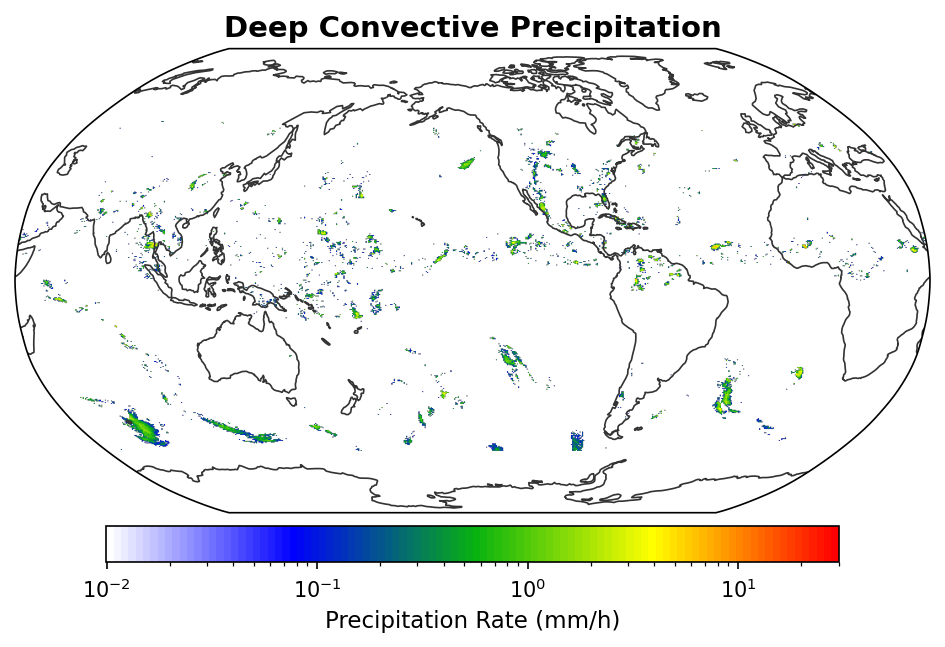


2. Stratiform Precipitation
------------------------------------------------------------


<Figure size 1800x1200 with 0 Axes>

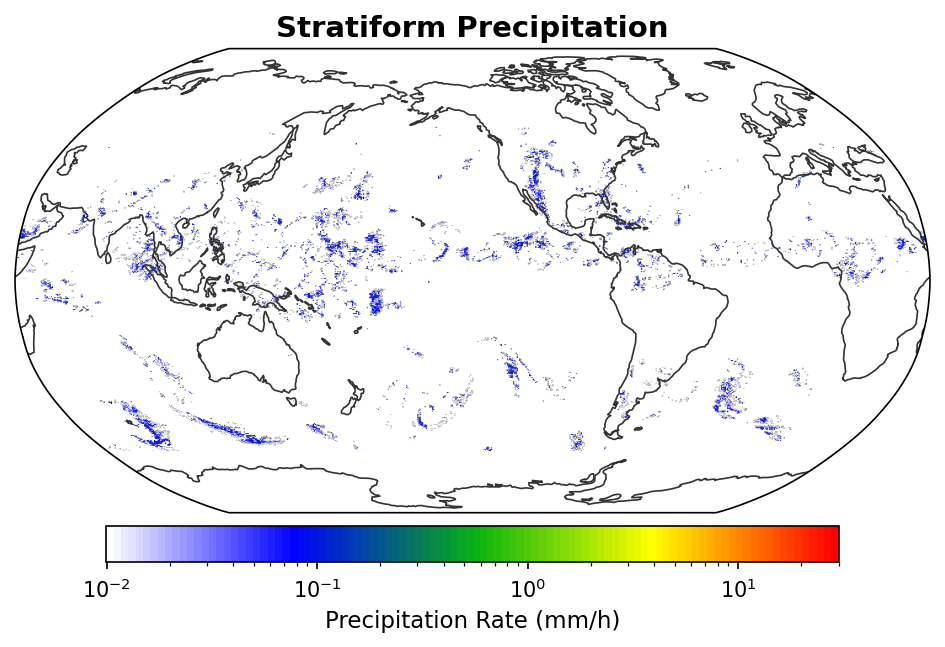


3. Non-Deep Convective Precipitation
------------------------------------------------------------


<Figure size 1800x1200 with 0 Axes>

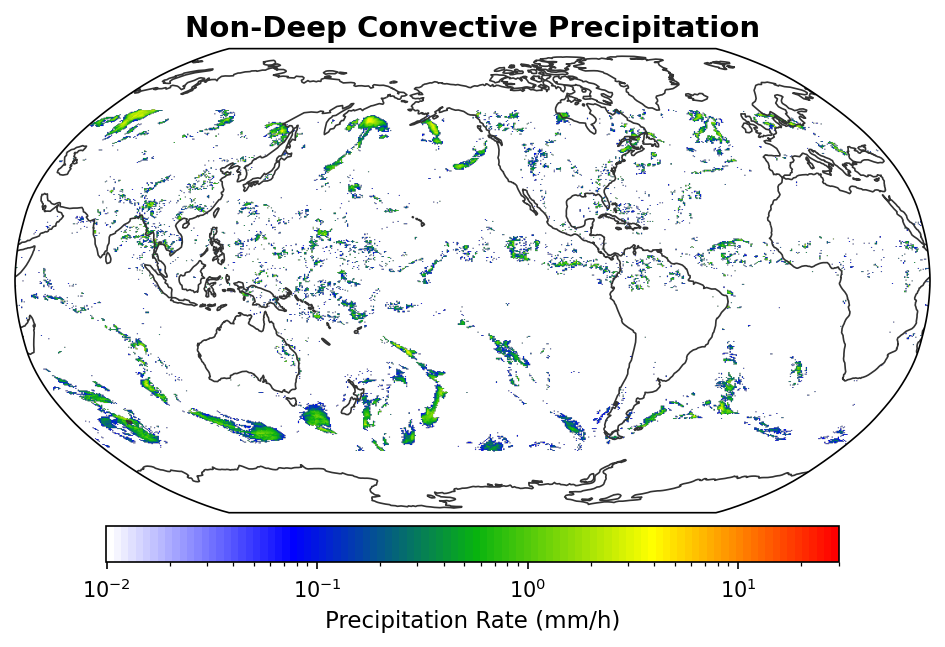


4. Drizzle Precipitation
------------------------------------------------------------


<Figure size 1800x1200 with 0 Axes>

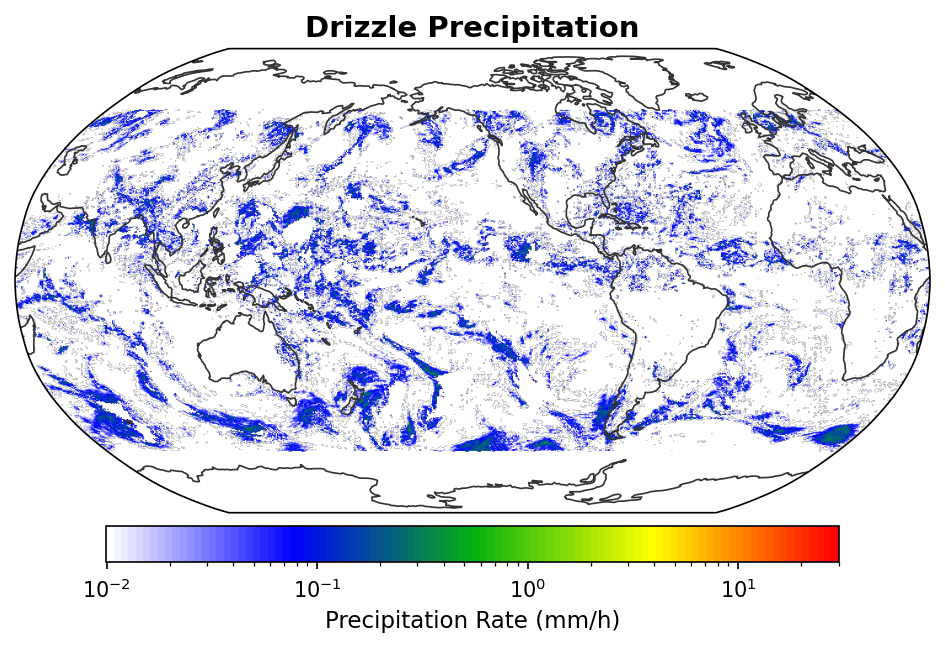

In [49]:
# Visualize the 4 precipitation types on HEALPix maps

# Create DataArrays for each precipitation type
dc_pr_da = xr.DataArray(
    dc_pr,
    dims=['cell'],
    coords={
        'lat': ('cell', test_ds['lat'].values),
        'lon': ('cell', test_ds['lon'].values),
        'cell': test_ds['cell'].values,
        'crs': test_ds['crs']
    },
    name='Deep Convective Precipitation'
)

st_pr_da = xr.DataArray(
    st_pr,
    dims=['cell'],
    coords={
        'lat': ('cell', test_ds['lat'].values),
        'lon': ('cell', test_ds['lon'].values),
        'cell': test_ds['cell'].values,
        'crs': test_ds['crs']
    },
    name='Stratiform Precipitation'
)

nd_pr_da = xr.DataArray(
    nd_pr,
    dims=['cell'],
    coords={
        'lat': ('cell', test_ds['lat'].values),
        'lon': ('cell', test_ds['lon'].values),
        'cell': test_ds['cell'].values,
        'crs': test_ds['crs']
    },
    name='Non-Deep Convective Precipitation'
)

dz_pr_da = xr.DataArray(
    dz_pr,
    dims=['cell'],
    coords={
        'lat': ('cell', test_ds['lat'].values),
        'lon': ('cell', test_ds['lon'].values),
        'cell': test_ds['cell'].values,
        'crs': test_ds['crs']
    },
    name='Drizzle Precipitation'
)

# Print statistics for each type
print("="*80)
print("PRECIPITATION BY CLOUD TYPE STATISTICS")
print("="*80)

for pr_type, pr_data, pr_name in [
    ('Deep Convective', dc_pr, 'dc_pr'),
    ('Stratiform', st_pr, 'st_pr'),
    ('Non-Deep Convective', nd_pr, 'nd_pr'),
    ('Drizzle', dz_pr, 'dz_pr')
]:
    valid_pr = pr_data[~np.isnan(pr_data)]
    print(f"\n{pr_type} Precipitation:")
    print(f"  Cells with data: {len(valid_pr):,}")
    if len(valid_pr) > 0:
        print(f"  Mean: {valid_pr.mean():.3f} mm/h")
        print(f"  Median: {np.median(valid_pr):.3f} mm/h")
        print(f"  Max: {valid_pr.max():.3f} mm/h")
        print(f"  Total: {valid_pr.sum():.2f} mm/h")

print("\n" + "="*80)

# Plot all 4 precipitation types (create separate figures since egh.healpix_show creates its own axes)
pr_types = [
    (dc_pr_da, 'Deep Convective Precipitation'),
    (st_pr_da, 'Stratiform Precipitation'),
    (nd_pr_da, 'Non-Deep Convective Precipitation'),
    (dz_pr_da, 'Drizzle Precipitation')
]

for i, (pr_da, title) in enumerate(pr_types, 1):
    print(f"\n{i}. {title}")
    print("-" * 60)
    fig = plt.figure(figsize=(12, 8))
    im = egh.healpix_show(
        pr_da.where(~np.isnan(pr_da)), 
        cmap=cmaps.WhBlGrYeRe, 
        norm=mpl.colors.LogNorm(vmin=0.01, vmax=30)
    )
    plt.title(title, fontsize=14, fontweight='bold')
    cbar = plt.colorbar(im, shrink=0.8, pad=0.02, orientation='horizontal')
    cbar.set_label('Precipitation Rate (mm/h)', fontsize=11)
    plt.tight_layout()
    plt.show()

<Figure size 960x720 with 0 Axes>

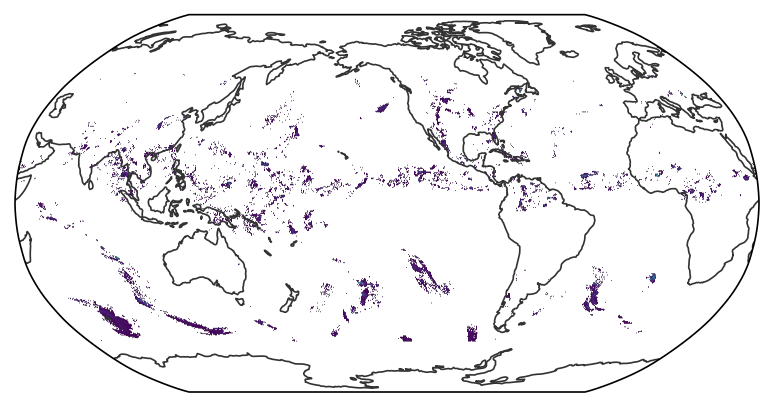

In [41]:
egh.healpix_show(dc_pr)

In [23]:
# Compare priority-based vs frequency-based aggregation
print("\n" + "="*80)
print("COMPARING AGGREGATION METHODS")
print("="*80)

# Priority-based aggregation
cloud_types_priority = find_priority_based_cloud_type(cloud_types_timeseries)

print(f"\n1. FREQUENCY-BASED (most frequent cloud type):")
print(f"   Cells with classified clouds: {(cloud_types_aggregated > 0).sum():,}")
for ct in range(1, 5):
    n_ct = (cloud_types_aggregated == ct).sum()
    pct = 100 * n_ct / (cloud_types_aggregated > 0).sum() if (cloud_types_aggregated > 0).sum() > 0 else 0
    cloud_names = ['', 'Deep convective', 'Stratiform', 'Non-deep convective', 'Drizzle']
    print(f"   Type {ct} ({cloud_names[ct]}): {n_ct:,} cells ({pct:.1f}%)")

print(f"\n2. PRIORITY-BASED (1 > 2 > 3 > 4):")
print(f"   Cells with classified clouds: {(cloud_types_priority > 0).sum():,}")
for ct in range(1, 5):
    n_ct = (cloud_types_priority == ct).sum()
    pct = 100 * n_ct / (cloud_types_priority > 0).sum() if (cloud_types_priority > 0).sum() > 0 else 0
    cloud_names = ['', 'Deep convective', 'Stratiform', 'Non-deep convective', 'Drizzle']
    print(f"   Type {ct} ({cloud_names[ct]}): {n_ct:,} cells ({pct:.1f}%)")

# Show differences
diff_cells = (cloud_types_aggregated != cloud_types_priority).sum()
print(f"\n3. DIFFERENCE:")
print(f"   Cells with different classification: {diff_cells:,} ({100*diff_cells/len(cloud_types_aggregated):.2f}%)")

# Show transition matrix (what frequency-based types became in priority-based)
print(f"\n4. TRANSITION MATRIX (Frequency -> Priority):")
print(f"   {'From\\To':<20} {'Type 0':<10} {'Type 1':<10} {'Type 2':<10} {'Type 3':<10} {'Type 4':<10}")
print(f"   {'-'*70}")
for from_type in range(0, 5):
    row = f"   Type {from_type:<15}"
    for to_type in range(0, 5):
        count = ((cloud_types_aggregated == from_type) & (cloud_types_priority == to_type)).sum()
        row += f" {count:<10,}"
    print(row)


COMPARING AGGREGATION METHODS

1. FREQUENCY-BASED (most frequent cloud type):
   Cells with classified clouds: 673,194
   Type 1 (Deep convective): 9,234 cells (1.4%)
   Type 2 (Stratiform): 18,109 cells (2.7%)
   Type 3 (Non-deep convective): 15,515 cells (2.3%)
   Type 4 (Drizzle): 630,336 cells (93.6%)

2. PRIORITY-BASED (1 > 2 > 3 > 4):
   Cells with classified clouds: 673,194
   Type 1 (Deep convective): 23,929 cells (3.6%)
   Type 2 (Stratiform): 41,037 cells (6.1%)
   Type 3 (Non-deep convective): 36,642 cells (5.4%)
   Type 4 (Drizzle): 571,586 cells (84.9%)

3. DIFFERENCE:
   Cells with different classification: 65,187 (8.29%)

4. TRANSITION MATRIX (Frequency -> Priority):
   From\To              Type 0     Type 1     Type 2     Type 3     Type 4    
   ----------------------------------------------------------------------
   Type 0               113,238    0          0          0          0         
   Type 1               0          9,234      0          0          0       


Panel 1: Frequency-Based Cloud Types (Most Frequent)
------------------------------------------------------------


<Figure size 1800x1200 with 0 Axes>

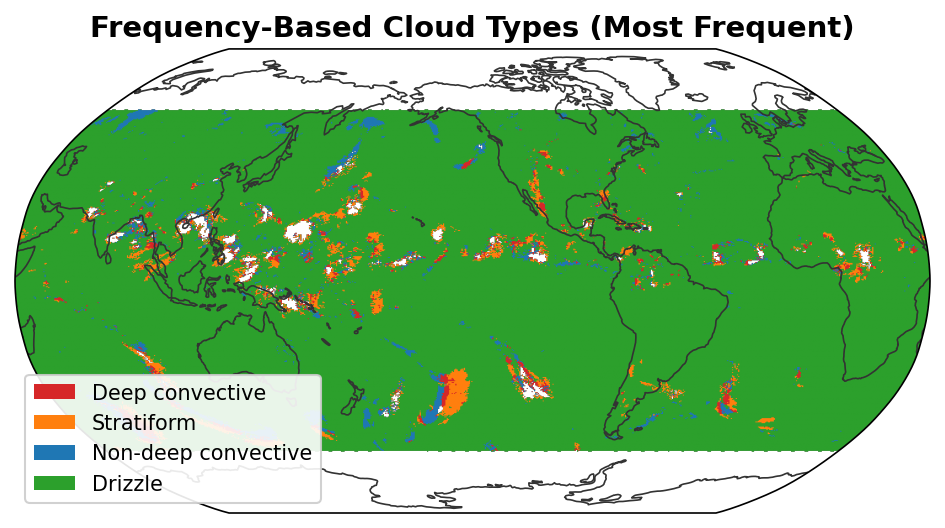


Panel 2: Priority-Based Cloud Types (1 > 2 > 3 > 4)
------------------------------------------------------------


<Figure size 1800x1200 with 0 Axes>

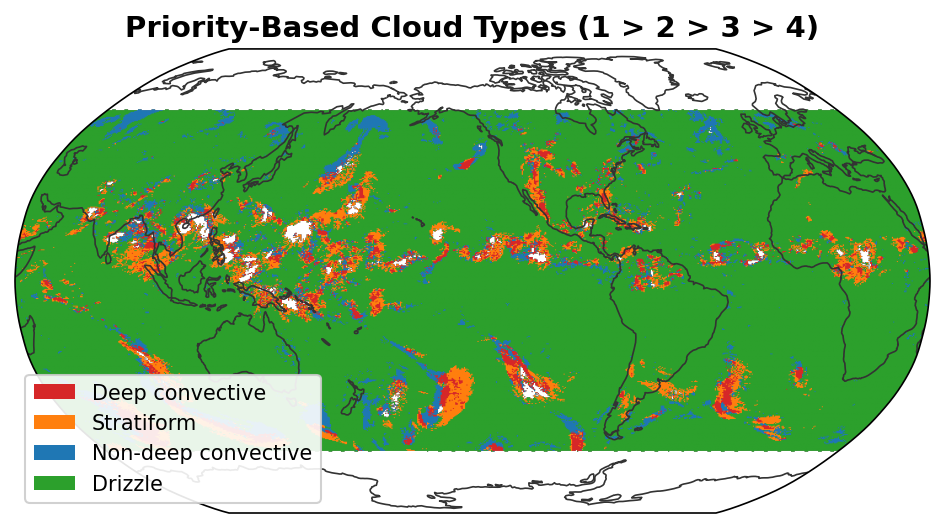


Panel 3: Difference Between Methods
------------------------------------------------------------


<Figure size 1800x1200 with 0 Axes>

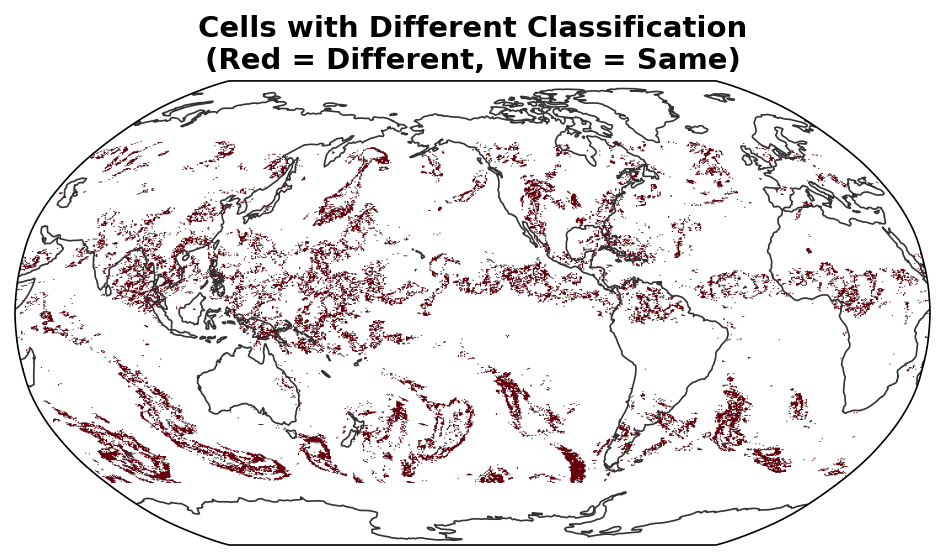


Difference: 65,187 cells (8.29%)


In [24]:
# Visualize comparison: Frequency-based vs Priority-based

cloud_types_da = xr.DataArray(
    cloud_types_aggregated,
    dims=['cell'],
    coords={
        'lat': ('cell', test_ds['lat'].values),
        'lon': ('cell', test_ds['lon'].values),
        'cell': test_ds['cell'].values,
        'crs': test_ds['crs']
    },
    name='Frequency-Based Cloud Types'
)

# Create DataArray for priority-based classification
cloud_types_priority_da = xr.DataArray(
    cloud_types_priority,
    dims=['cell'],
    coords={
        'lat': ('cell', test_ds['lat'].values),
        'lon': ('cell', test_ds['lon'].values),
        'cell': test_ds['cell'].values,
        'crs': test_ds['crs']
    },
    name='Priority-Based Cloud Types'
)

# Define colors
cloud_colors = {
    1: '#d62728',  # Deep convective - red
    2: '#ff7f0e',  # Stratiform - orange
    3: '#1f77b4',  # Non-deep convective - blue
    4: '#2ca02c',  # Drizzle - green
}
cloud_labels = {
    1: 'Deep convective',
    2: 'Stratiform',
    3: 'Non-deep convective',
    4: 'Drizzle'
}
cloud_cmap = mcolors.ListedColormap([cloud_colors[i] for i in range(1, 5)])

# Panel 1: Frequency-based
print("\nPanel 1: Frequency-Based Cloud Types (Most Frequent)")
print("-" * 60)
fig1 = plt.figure(figsize=(12, 8))
im1 = egh.healpix_show(cloud_types_da.where(cloud_types_da > 0), 
                        cmap=cloud_cmap, 
                        vmin=0.5, vmax=4.5)
plt.title('Frequency-Based Cloud Types (Most Frequent)', fontsize=14, fontweight='bold')
legend_elements = [Patch(facecolor=cloud_colors[i], label=cloud_labels[i]) 
                   for i in range(1, 5)]
plt.legend(handles=legend_elements, loc='lower left', fontsize=10, framealpha=0.9)
plt.tight_layout()
plt.show()

# Panel 2: Priority-based
print("\nPanel 2: Priority-Based Cloud Types (1 > 2 > 3 > 4)")
print("-" * 60)
fig2 = plt.figure(figsize=(12, 8))
im2 = egh.healpix_show(cloud_types_priority_da.where(cloud_types_priority_da > 0), 
                        cmap=cloud_cmap, 
                        vmin=0.5, vmax=4.5)
plt.title('Priority-Based Cloud Types (1 > 2 > 3 > 4)', fontsize=14, fontweight='bold')
legend_elements = [Patch(facecolor=cloud_colors[i], label=cloud_labels[i]) 
                   for i in range(1, 5)]
plt.legend(handles=legend_elements, loc='lower left', fontsize=10, framealpha=0.9)
plt.tight_layout()
plt.show()

# Panel 3: Difference map
print("\nPanel 3: Difference Between Methods")
print("-" * 60)
diff_map = (cloud_types_aggregated != cloud_types_priority).astype(int)
diff_da = xr.DataArray(
    diff_map,
    dims=['cell'],
    coords={
        'lat': ('cell', test_ds['lat'].values),
        'lon': ('cell', test_ds['lon'].values),
        'cell': test_ds['cell'].values,
        'crs': test_ds['crs']
    },
    name='Difference'
)
fig3 = plt.figure(figsize=(12, 8))
im3 = egh.healpix_show(diff_da.where(diff_da > 0), cmap='Reds', vmin=0, vmax=1)
plt.title('Cells with Different Classification\n(Red = Different, White = Same)', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nDifference: {diff_cells:,} cells ({100*diff_cells/len(cloud_types_aggregated):.2f}%)")

In [25]:
# Apply MCS priority: Set cloud type to 0 where MCS swath exists
# MCS takes priority - if a cell has an MCS at any time, it should not have a cloud type
print("\nApplying MCS priority filter...")
print(f"  Before MCS filter: {(cloud_types_aggregated > 0).sum():,} cells with cloud types")

# Where combined_mcs_swath > 0, set cloud_types_aggregated to 0
cloud_types_aggregated_filtered = np.where(combined_mcs_swath > 0, 0, cloud_types_aggregated)

print(f"  After MCS filter: {(cloud_types_aggregated_filtered > 0).sum():,} cells with cloud types")
print(f"  Removed {(cloud_types_aggregated > 0).sum() - (cloud_types_aggregated_filtered > 0).sum():,} cells due to MCS overlap")

print(f"\nFiltered Cloud type distribution:")
for ct in range(1, 5):
    n_ct = (cloud_types_aggregated_filtered == ct).sum()
    if (cloud_types_aggregated_filtered > 0).sum() > 0:
        pct = 100 * n_ct / (cloud_types_aggregated_filtered > 0).sum()
    else:
        pct = 0
    cloud_names = ['', 'Deep convective', 'Stratiform', 'Non-deep convective', 'Drizzle']
    print(f"  Type {ct} ({cloud_names[ct]}): {n_ct:,} cells ({pct:.1f}%)")

# Update cloud_types_aggregated to the filtered version
cloud_types_aggregated = cloud_types_aggregated_filtered


Applying MCS priority filter...
  Before MCS filter: 673,194 cells with cloud types
  After MCS filter: 640,477 cells with cloud types
  Removed 32,717 cells due to MCS overlap

Filtered Cloud type distribution:
  Type 1 (Deep convective): 4,746 cells (0.7%)
  Type 2 (Stratiform): 9,810 cells (1.5%)
  Type 3 (Non-deep convective): 11,191 cells (1.7%)
  Type 4 (Drizzle): 614,730 cells (96.0%)


## 6. Visualize Results

Visualize the MCS swaths and cloud type classification on the HEALPix grid.

In [26]:
# Create DataArrays for visualization with CRS coordinate
mcs_swath_da = xr.DataArray(
    combined_mcs_swath,
    dims=['cell'],
    coords={
        'lat': ('cell', test_ds['lat'].values),
        'lon': ('cell', test_ds['lon'].values),
        'cell': test_ds['cell'].values,
        'crs': test_ds['crs']  # Add CRS coordinate for HEALPix projection
    },
    name='MCS Swath'
)

cloud_types_da = xr.DataArray(
    cloud_types_aggregated,
    dims=['cell'],
    coords={
        'lat': ('cell', test_ds['lat'].values),
        'lon': ('cell', test_ds['lon'].values),
        'cell': test_ds['cell'].values,
        'crs': test_ds['crs']  # Add CRS coordinate for HEALPix projection
    },
    name='Cloud Types'
)

In [27]:
# test_ds['pr'].isel(time=0).plot.hist()
# np.count_nonzero(np.isnan(test_ds['pr'].isel(time=0)))
# test_ds['pr'].where()
# cloud_types_timeseries.shape

## Investigate Classification Logic

Let's examine the classification logic and visualize one timestep to understand why areas aren't classified as drizzle.

In [28]:
# Select one timestep to investigate (t=0)
t_idx = 0

tb_t = test_ds['tb'].isel(time=t_idx).values
pr_t = test_ds['pr'].isel(time=t_idx).values
mcs_mask_t = test_ds['mcs_mask'].isel(time=t_idx).values

# Replace NaN with 0
mcs_mask_t = np.nan_to_num(mcs_mask_t, nan=0.0).astype(int)

# The valid_mask is now simply non-MCS areas (where mcs_mask == 0)
valid_mask = mcs_mask_t == 0

print(f"Investigating timestep {t_idx}: {test_ds.time.values[t_idx]}")
print("=" * 80)

# Check for NaN values
print(f"\nNaN Statistics:")
print(f"  tb NaN count: {np.isnan(tb_t).sum():,} / {len(tb_t):,}")
print(f"  pr NaN count: {np.isnan(pr_t).sum():,} / {len(pr_t):,}")
print(f"  pr == 0 count: {(pr_t == 0).sum():,} / {len(pr_t):,}")

# Check valid_mask (non-MCS areas)
print(f"\nValid Mask (non-MCS) Statistics:")
print(f"  MCS cells (mcs_mask > 0): {(mcs_mask_t > 0).sum():,}")
print(f"  Non-MCS cells (mcs_mask == 0): {(valid_mask).sum():,}")

print(f"\n  ✅ UPDATED: Classification now happens in ALL non-MCS areas!")
print(f"  This includes {valid_mask.sum():,} cells")

# Among valid mask cells, check conditions
if valid_mask.sum() > 0:
    print(f"\nAmong {valid_mask.sum():,} non-MCS cells:")
    print(f"  tb < tb_thresh: {((tb_t < tb_thresh) & valid_mask).sum():,}")
    print(f"  tb >= tb_thresh: {((tb_t >= tb_thresh) & valid_mask).sum():,}")
    print(f"  pr >= 0.5: {((pr_t >= 0.5) & valid_mask).sum():,}")
    print(f"  pr < 0.5: {((pr_t < 0.5) & valid_mask).sum():,}")
    
    # Check each cloud type condition
    deep_conv = (tb_t < tb_thresh) & (pr_t >= 0.5) & valid_mask
    stratiform = (tb_t < tb_thresh) & (pr_t < 0.5) & valid_mask
    nondeep_conv = (tb_t >= tb_thresh) & (pr_t >= 0.5) & valid_mask
    drizzle = (tb_t >= tb_thresh) & (pr_t < 0.5) & valid_mask
    
    print(f"\nCloud type breakdown:")
    print(f"  Deep convective (tb < tb_thresh & pr >= 0.5): {deep_conv.sum():,}")
    print(f"  Stratiform (tb < tb_thresh & pr < 0.5): {stratiform.sum():,}")
    print(f"  Non-deep convective (tb >= tb_thresh & pr >= 0.5): {nondeep_conv.sum():,}")
    print(f"  Drizzle (tb >= tb_thresh & pr < 0.5): {drizzle.sum():,}")
    print(f"\n  ✅ Now most non-MCS areas will be classified!")

Investigating timestep 0: 2019-08-01T00:00:00.000000000

NaN Statistics:
  tb NaN count: 105,826 / 786,432
  pr NaN count: 105,624 / 786,432
  pr == 0 count: 526,863 / 786,432

Valid Mask (non-MCS) Statistics:
  MCS cells (mcs_mask > 0): 19,614
  Non-MCS cells (mcs_mask == 0): 766,818

  ✅ UPDATED: Classification now happens in ALL non-MCS areas!
  This includes 766,818 cells

Among 766,818 non-MCS cells:
  tb < tb_thresh: 25,926
  tb >= tb_thresh: 635,066
  pr >= 0.5: 24,340
  pr < 0.5: 636,854

Cloud type breakdown:
  Deep convective (tb < tb_thresh & pr >= 0.5): 7,965
  Stratiform (tb < tb_thresh & pr < 0.5): 17,961
  Non-deep convective (tb >= tb_thresh & pr >= 0.5): 16,360
  Drizzle (tb >= tb_thresh & pr < 0.5): 618,706

  ✅ Now most non-MCS areas will be classified!



1. Brightness Temperature at t=0
------------------------------------------------------------


<Figure size 1800x1200 with 0 Axes>

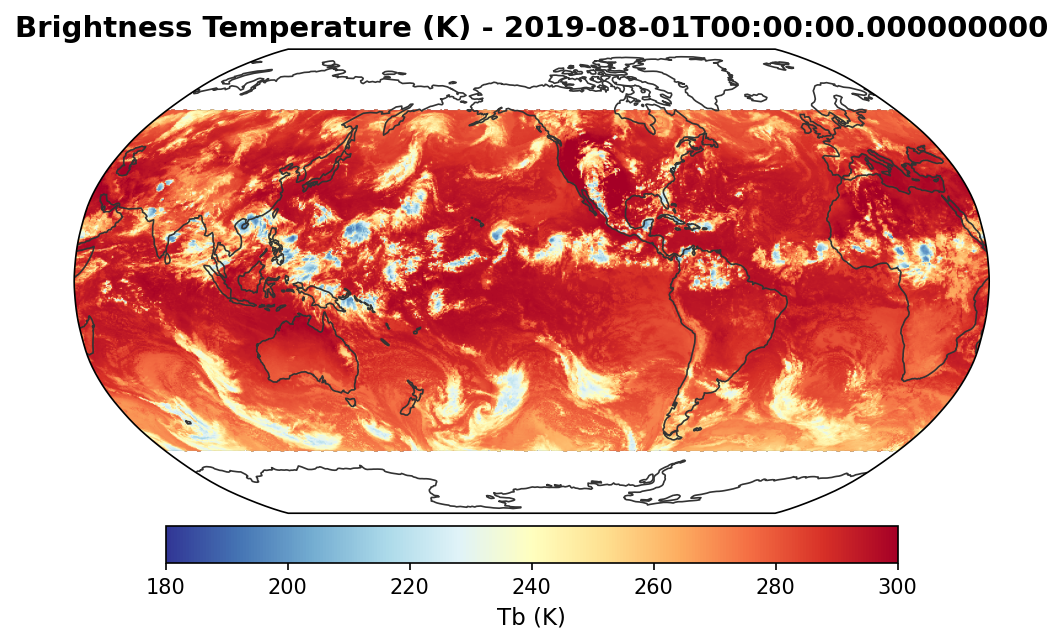


2. Precipitation Rate at t=0
------------------------------------------------------------


<Figure size 1800x1200 with 0 Axes>

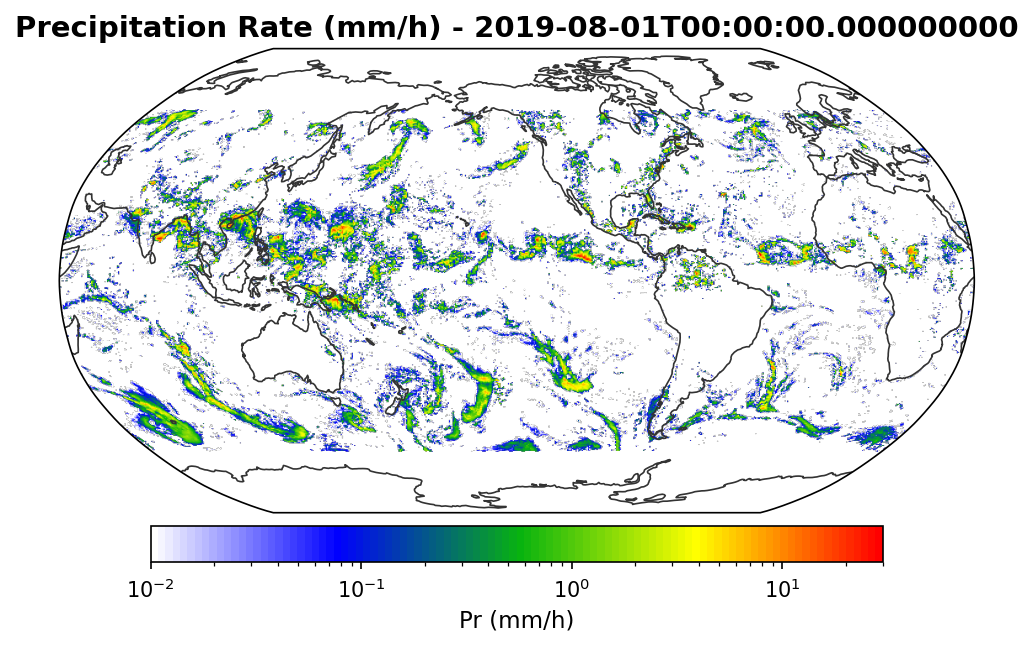


3. MCS Mask at t=0
------------------------------------------------------------


<Figure size 1800x1200 with 0 Axes>

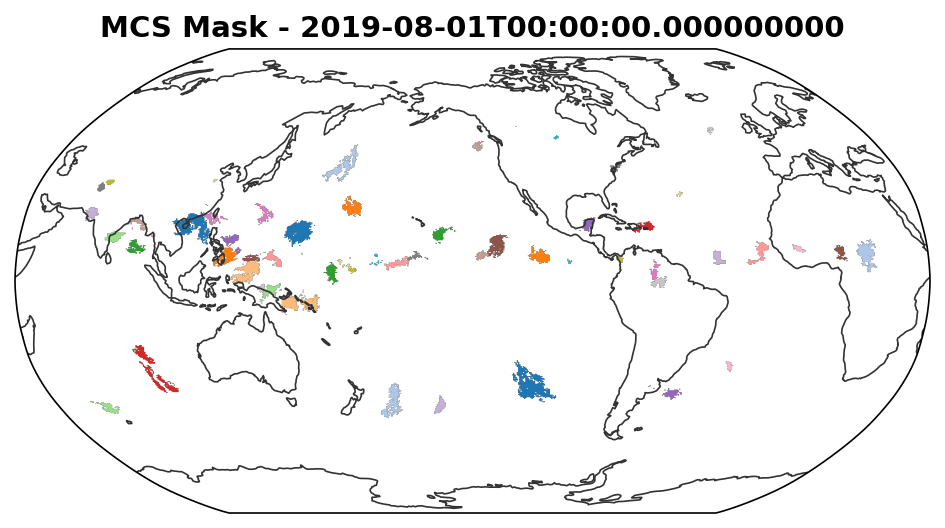


4. Cloud Type Classification at t=0
------------------------------------------------------------


<Figure size 1800x1200 with 0 Axes>

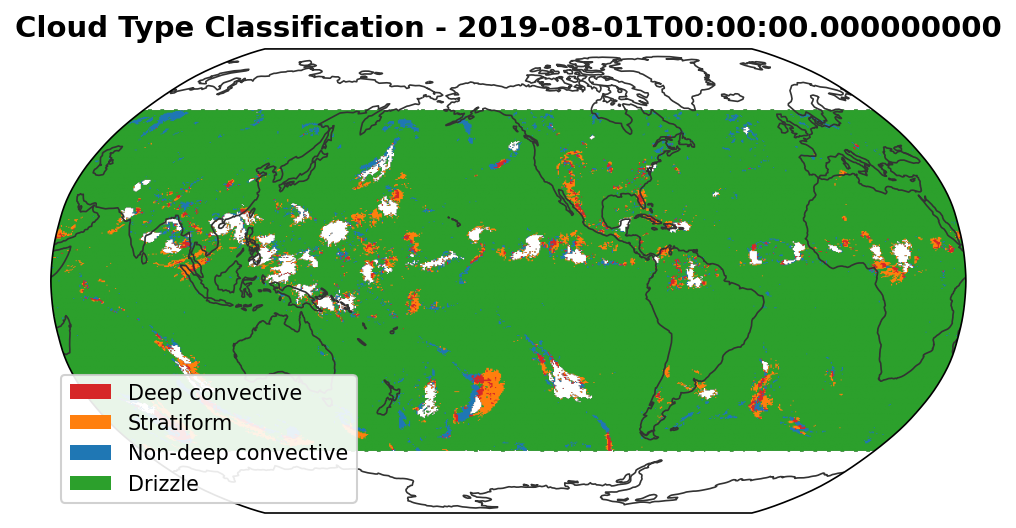

In [29]:
# Visualize the key variables for this timestep

# Create DataArrays for visualization
tb_t_da = xr.DataArray(
    tb_t,
    dims=['cell'],
    coords={
        'lat': ('cell', test_ds['lat'].values),
        'lon': ('cell', test_ds['lon'].values),
        'cell': test_ds['cell'].values,
        'crs': test_ds['crs']
    },
    name='Brightness Temperature (K)'
)

pr_t_da = xr.DataArray(
    pr_t,
    dims=['cell'],
    coords={
        'lat': ('cell', test_ds['lat'].values),
        'lon': ('cell', test_ds['lon'].values),
        'cell': test_ds['cell'].values,
        'crs': test_ds['crs']
    },
    name='Precipitation Rate (mm/h)'
)

mcs_mask_t_da = xr.DataArray(
    mcs_mask_t,
    dims=['cell'],
    coords={
        'lat': ('cell', test_ds['lat'].values),
        'lon': ('cell', test_ds['lon'].values),
        'cell': test_ds['cell'].values,
        'crs': test_ds['crs']
    },
    name='MCS Mask'
)

cloud_type_t_da = xr.DataArray(
    cloud_types_timeseries[t_idx],
    dims=['cell'],
    coords={
        'lat': ('cell', test_ds['lat'].values),
        'lon': ('cell', test_ds['lon'].values),
        'cell': test_ds['cell'].values,
        'crs': test_ds['crs']
    },
    name='Cloud Type Classification'
)

# Plot Tb
print(f"\n1. Brightness Temperature at t={t_idx}")
print("-" * 60)
fig = plt.figure(figsize=(12, 8))
im = egh.healpix_show(tb_t_da, cmap='RdYlBu_r', vmin=180, vmax=300)
plt.title(f'Brightness Temperature (K) - {test_ds.time.values[t_idx]}', fontsize=14, fontweight='bold')
cbar = plt.colorbar(im, shrink=0.8, pad=0.02, orientation='horizontal')
cbar.set_label('Tb (K)', fontsize=11)
plt.tight_layout()
plt.show()

# Plot Pr
print(f"\n2. Precipitation Rate at t={t_idx}")
print("-" * 60)
fig = plt.figure(figsize=(12, 8))
im = egh.healpix_show(pr_t_da.where(pr_t_da > 0), 
                       cmap=cmaps.WhBlGrYeRe, 
                       norm=mpl.colors.LogNorm(vmin=0.01, vmax=30))
plt.title(f'Precipitation Rate (mm/h) - {test_ds.time.values[t_idx]}', fontsize=14, fontweight='bold')
cbar = plt.colorbar(im, shrink=0.8, pad=0.02, orientation='horizontal')
cbar.set_label('Pr (mm/h)', fontsize=11)
plt.tight_layout()
plt.show()

# Plot MCS mask
print(f"\n3. MCS Mask at t={t_idx}")
print("-" * 60)
fig = plt.figure(figsize=(12, 8))
im = egh.healpix_show(mcs_mask_t_da.where(mcs_mask_t_da > 0), cmap='tab20')
plt.title(f'MCS Mask - {test_ds.time.values[t_idx]}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Plot cloud type classification
print(f"\n4. Cloud Type Classification at t={t_idx}")
print("-" * 60)
# Define colors and labels for cloud types
cloud_colors = {
    1: '#d62728',  # Deep convective - red
    2: '#ff7f0e',  # Stratiform - orange
    3: '#1f77b4',  # Non-deep convective - blue
    4: '#2ca02c',  # Drizzle - green
}
cloud_labels = {
    1: 'Deep convective',
    2: 'Stratiform',
    3: 'Non-deep convective',
    4: 'Drizzle'
}
cloud_cmap = mcolors.ListedColormap([cloud_colors[i] for i in range(1, 5)])
fig = plt.figure(figsize=(12, 8))
im = egh.healpix_show(cloud_type_t_da.where(cloud_type_t_da > 0), 
                       cmap=cloud_cmap, 
                       vmin=0.5, vmax=4.5)
plt.title(f'Cloud Type Classification - {test_ds.time.values[t_idx]}', fontsize=14, fontweight='bold')
legend_elements = [Patch(facecolor=cloud_colors[i], label=cloud_labels[i]) 
                   for i in range(1, 5)]
plt.legend(handles=legend_elements, loc='lower left', fontsize=10, framealpha=0.9)
plt.tight_layout()
plt.show()

### Analysis Summary - UPDATED

**✅ FIXED: Removed the CCS mask requirement!**

The updated classification logic now classifies ALL non-MCS pixels:
- `valid_mask = (mcs_mask == 0)` - classifies everywhere EXCEPT MCS regions

This means:
- **Most of the globe IS NOW classified** (all non-MCS areas)
- Areas with `tb >= tb_thresh` and `pr < 0.5` are now classified as "drizzle" everywhere outside MCS regions
- Areas with `tb >= tb_thresh` and `pr == 0` are also classified as "drizzle"
- Only MCS regions remain unclassified (cloud_type = 0)

**The classification now works as intended:** Tb thresholds and precipitation rates determine cloud types across all non-MCS areas!

<Figure size 2100x1200 with 0 Axes>

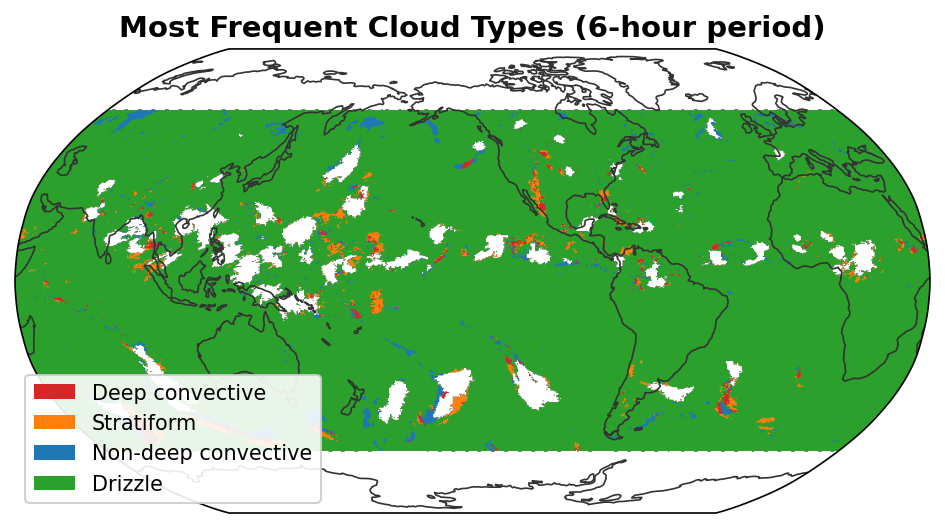

In [30]:
# Plot cloud types with custom colors

# Define colors and labels for cloud types
cloud_colors = {
    1: '#d62728',  # Deep convective - red
    2: '#ff7f0e',  # Stratiform - orange
    3: '#1f77b4',  # Non-deep convective - blue
    4: '#2ca02c',  # Drizzle - green
}
cloud_labels = {
    1: 'Deep convective',
    2: 'Stratiform',
    3: 'Non-deep convective',
    4: 'Drizzle'
}

# Create custom colormap
cmap = mcolors.ListedColormap([cloud_colors[i] for i in range(1, 5)])

# Plot cloud type classification
fig = plt.figure(figsize=(14, 8))
im = egh.healpix_show(cloud_types_da.where(cloud_types_da > 0), 
                       cmap=cmap, 
                       vmin=0.5, vmax=4.5)
plt.title('Most Frequent Cloud Types (6-hour period)', fontsize=14, fontweight='bold')

# Create custom legend
legend_elements = [Patch(facecolor=cloud_colors[i], label=cloud_labels[i]) 
                   for i in range(1, 5)]
plt.legend(handles=legend_elements, loc='lower left', fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.show()

In [31]:
# Calculate 6-hourly mean precipitation rate
pr_mean = test_ds['pr'].mean(dim='time')
pr_mean
# # Create DataArray for precipitation with CRS
# pr_mean_da = xr.DataArray(
#     pr_mean.values,
#     dims=['cell'],
#     coords={
#         'lat': ('cell', test_ds['lat'].values),
#         'lon': ('cell', test_ds['lon'].values),
#         'cell': test_ds['cell'].values,
#         'crs': test_ds['crs']
#     },
#     name='Mean Precipitation Rate'
# )

<xarray.DataArray 'pr' (cell: 786432)> Size: 3MB
array([0., 0., 0., ..., 0., 0., 0.], dtype=float32)
Coordinates:
    crs      int64 8B 0
  * cell     (cell) int32 3MB 0 1 2 3 4 5 ... 786427 786428 786429 786430 786431
    lat      (cell) float64 6MB 0.1492 0.2984 0.2984 ... -0.2984 -0.2984 -0.1492
    lon      (cell) float64 6MB 45.0 45.18 44.82 45.0 ... 315.2 314.8 315.0

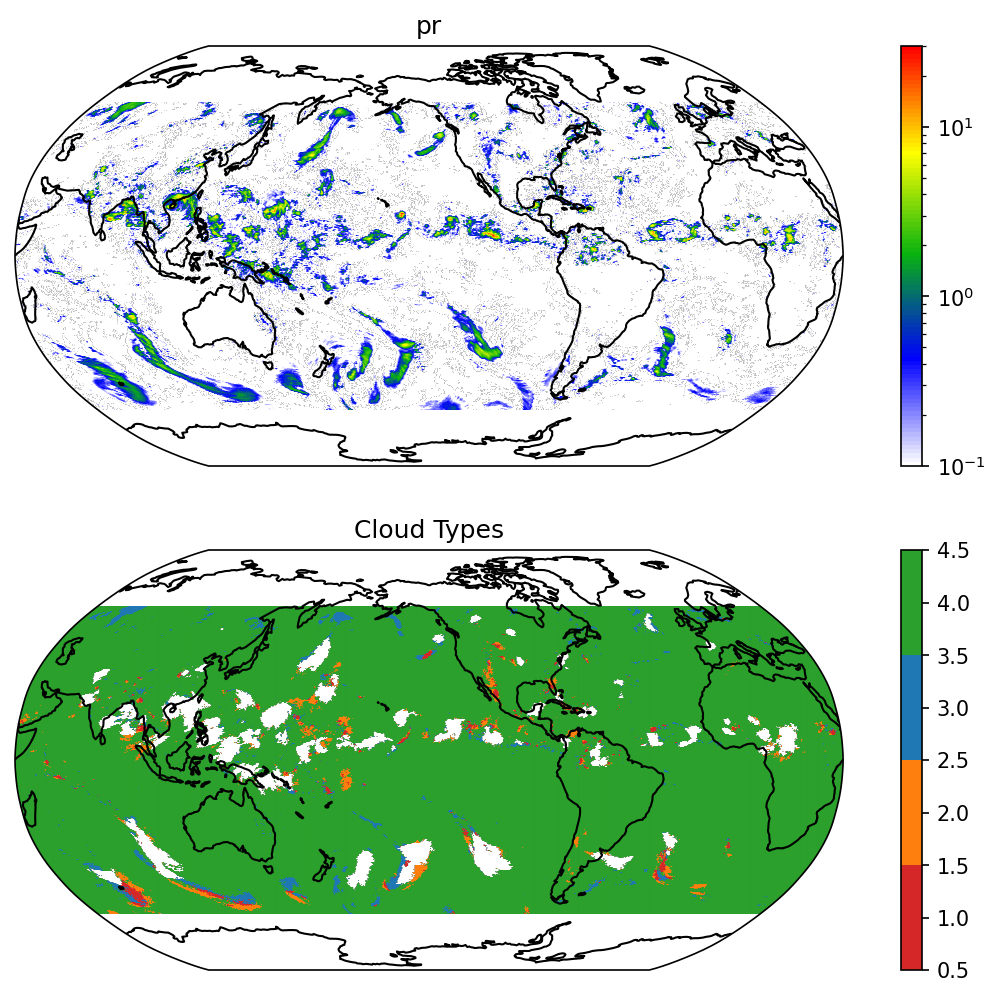

In [32]:
# Define colors for cloud types
cloud_colors = {
    1: '#d62728',  # Deep convective - red
    2: '#ff7f0e',  # Stratiform - orange
    3: '#1f77b4',  # Non-deep convective - blue
    4: '#2ca02c',  # Drizzle - green
}
cloud_labels = {
    1: 'Deep convective',
    2: 'Stratiform',
    3: 'Non-deep convective',
    4: 'Drizzle'
}
# Create custom colormap for cloud types
cloud_cmap = mcolors.ListedColormap([cloud_colors[i] for i in range(1, 5)])
pr_cmap = cmaps.WhBlGrYeRe

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(10, 8), subplot_kw={'projection': ccrs.Robinson(central_longitude=-137)})
def egh_plot(data, ax, **kwargs):
    ax.set_title(data.name)
    ax.set_global()
    im = egh.healpix_show(data, ax=ax, **kwargs)
    plt.colorbar(im, ax=ax)
    ax.coastlines()

egh_plot(pr_mean, norm=mpl.colors.LogNorm(vmin=10e-2, vmax=30), cmap=pr_cmap, ax=ax0)
egh_plot(cloud_types_da.where(cloud_types_da > 0), cmap=cloud_cmap, vmin=0.5, vmax=4.5, ax=ax1)

# egh_plot(ds.precipitation.sel(time=time), ax=ax0, norm=mpl.colors.LogNorm(vmin=10e-2, vmax=30), cmap=cmaps.WhBlGrYeRe)
# egh_plot(ds.Tb.sel(time=time), ax=ax1, cmap=cmap_tb, vmin=180, vmax=315)
# fig.suptitle(f'{time} (zoom {zoom})', fontsize=16)

Panel 1: 6-hourly Mean Precipitation Rate
------------------------------------------------------------


<Figure size 1800x1200 with 0 Axes>

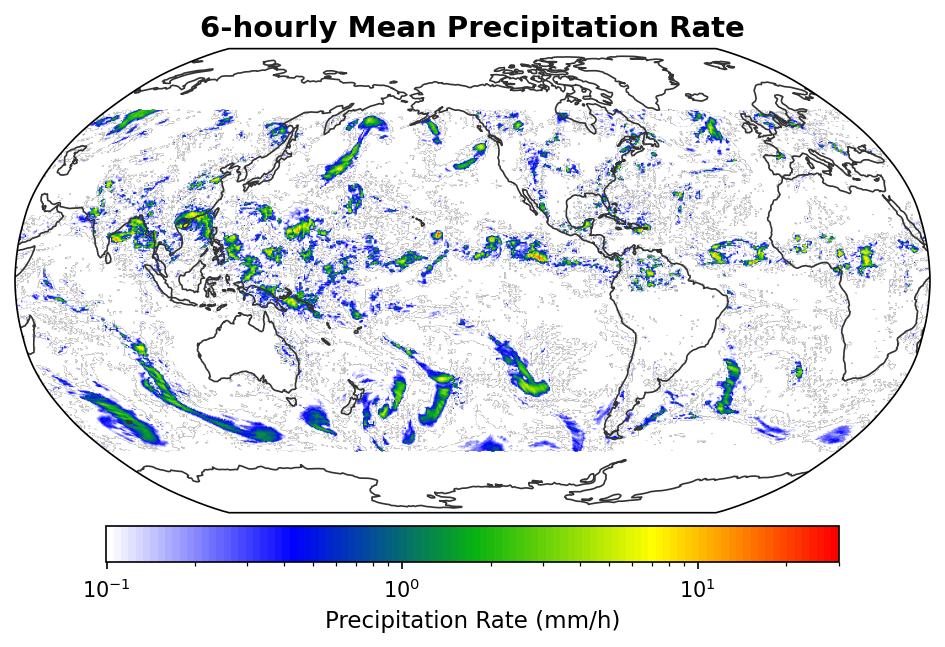


Panel 2: Most Frequent Cloud Types
------------------------------------------------------------


<Figure size 1800x1200 with 0 Axes>

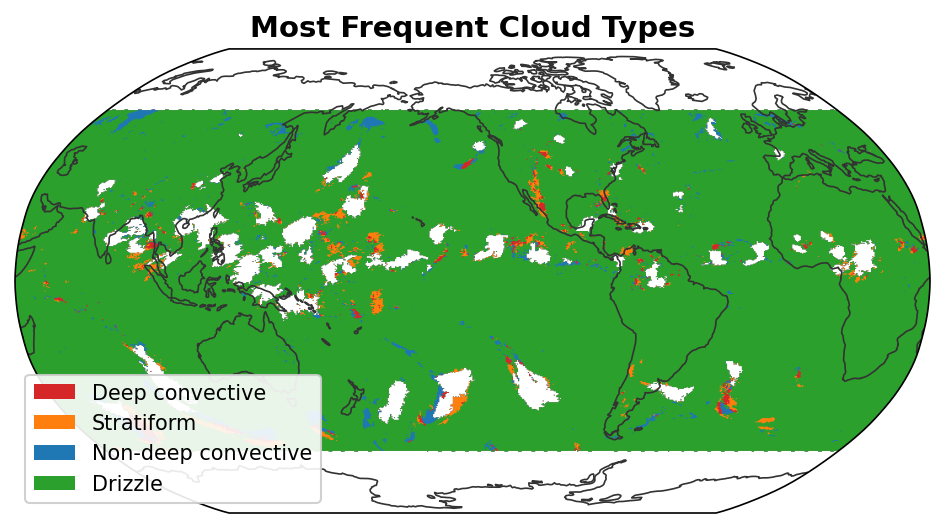


6-hourly Mean Precipitation Statistics:
  Mean: 0.32 mm/h
  Max: nan mm/h
  Cells with precipitation > 0: 268,461


In [33]:
# Create 2-panel visualization: Mean precipitation rate and cloud types

# Define colors for cloud types
cloud_colors = {
    1: '#d62728',  # Deep convective - red
    2: '#ff7f0e',  # Stratiform - orange
    3: '#1f77b4',  # Non-deep convective - blue
    4: '#2ca02c',  # Drizzle - green
}
cloud_labels = {
    1: 'Deep convective',
    2: 'Stratiform',
    3: 'Non-deep convective',
    4: 'Drizzle'
}

# Create custom colormap for cloud types
cloud_cmap = mcolors.ListedColormap([cloud_colors[i] for i in range(1, 5)])

# Panel 1: 6-hourly mean precipitation rate
print("Panel 1: 6-hourly Mean Precipitation Rate")
print("-" * 60)
fig1 = plt.figure(figsize=(12, 8))
# im1 = egh.healpix_show(pr_mean.where(pr_mean > 0), 
im1 = egh.healpix_show(pr_mean, 
                        cmap=cmaps.WhBlGrYeRe, norm=mpl.colors.LogNorm(vmin=10e-2, vmax=30))
                        # vmin=0, vmax=10)
plt.title('6-hourly Mean Precipitation Rate', fontsize=14, fontweight='bold')
cbar1 = plt.colorbar(im1, shrink=0.8, pad=0.02, orientation='horizontal')
cbar1.set_label('Precipitation Rate (mm/h)', fontsize=11)
plt.tight_layout()
plt.show()

# Panel 2: 6-hourly cloud types
print("\nPanel 2: Most Frequent Cloud Types")
print("-" * 60)
fig2 = plt.figure(figsize=(12, 8))
im2 = egh.healpix_show(cloud_types_da.where(cloud_types_da > 0), 
                        cmap=cloud_cmap, 
                        vmin=0.5, vmax=4.5)
plt.title('Most Frequent Cloud Types', fontsize=14, fontweight='bold')

# Create custom legend for cloud types
legend_elements = [Patch(facecolor=cloud_colors[i], label=cloud_labels[i]) 
                   for i in range(1, 5)]
plt.legend(handles=legend_elements, loc='lower left', fontsize=10, framealpha=0.9)
plt.tight_layout()
plt.show()

# Print statistics
print(f"\n6-hourly Mean Precipitation Statistics:")
print(f"  Mean: {pr_mean.values[pr_mean.values > 0].mean():.2f} mm/h")
print(f"  Max: {pr_mean.values.max():.2f} mm/h")
print(f"  Cells with precipitation > 0: {(pr_mean.values > 0).sum():,}")

## 7. Summary Statistics

Compute and display summary statistics for the test period.

In [34]:
print("="*80)
print("SUMMARY STATISTICS")
print("="*80)

print(f"\nTest Period:")
print(f"  Start: {test_ds.time.values[0]}")
print(f"  End: {test_ds.time.values[-1]}")
print(f"  Duration: {len(test_ds.time)} hours")

print(f"\nMCS Swaths:")
print(f"  Total unique tracks: {len(mcs_swaths_dict)}")
print(f"  Total swath pixels: {(combined_mcs_swath > 0).sum():,}")
print(f"  Swath coverage: {100 * (combined_mcs_swath > 0).sum() / len(combined_mcs_swath):.2f}%")

print(f"\nCloud Type Classification:")
print(f"  Total classified cells: {(cloud_types_aggregated > 0).sum():,}")
print(f"  Classification coverage: {100 * (cloud_types_aggregated > 0).sum() / len(cloud_types_aggregated):.2f}%")

print(f"\n  Cloud Type Distribution:")
cloud_names = ['No cloud', 'Deep convective', 'Stratiform', 'Non-deep convective', 'Drizzle']
for ct in range(1, 5):
    n_ct = (cloud_types_aggregated == ct).sum()
    pct = 100 * n_ct / (cloud_types_aggregated > 0).sum() if (cloud_types_aggregated > 0).sum() > 0 else 0
    print(f"    {cloud_names[ct]}: {n_ct:,} cells ({pct:.1f}%)")

print(f"\n{'='*80}")

SUMMARY STATISTICS

Test Period:
  Start: 2019-08-01T00:00:00.000000000
  End: 2019-08-01T05:00:00.000000000
  Duration: 6 hours

MCS Swaths:
  Total unique tracks: 81
  Total swath pixels: 40,235
  Swath coverage: 5.12%

Cloud Type Classification:
  Total classified cells: 640,477
  Classification coverage: 81.44%

  Cloud Type Distribution:
    Deep convective: 4,746 cells (0.7%)
    Stratiform: 9,810 cells (1.5%)
    Non-deep convective: 11,191 cells (1.7%)
    Drizzle: 614,730 cells (96.0%)

